In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('web-scrape/baringo_weather_data_2010_2020.csv')

In [47]:
# Remove the rows that had missing values
df = df.dropna()

# Remove the raw columns
columns = ['temperature_raw', 'dew_point_raw', 'humidity_raw', 'wind_speed_raw', 
           'pressure_raw', 'precipitation_raw']

df = df.drop(columns, axis=1)

df.to_csv('baringo-data.csv')

In [48]:
# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    4018 non-null   float64
 1   dew_point      4018 non-null   float64
 2   humidity       4018 non-null   float64
 3   wind_speed     4018 non-null   float64
 4   pressure       4018 non-null   float64
 5   precipitation  4018 non-null   float64
dtypes: float64(6)
memory usage: 219.7 KB


In [49]:
# Define the flood probability function
def calculate_flood_probability(df):
    df['3_day_cum_precip'] = df['precipitation'].rolling(window=3).sum()

    # Normalize features (min-max scaling)
    df['norm_precip'] = df['3_day_cum_precip'] / df['3_day_cum_precip'].max()
    df['norm_humidity'] = df['humidity'] / df['humidity'].max()
    df['norm_dew_point'] = df['dew_point'] / df['dew_point'].max()
    df['norm_pressure'] = 1 - (df['pressure'] / df['pressure'].max())  # Inverse scaling

    # Weighted sum of features (tuned weights based on analysis)
    df['flood_probability'] = (
        (df['norm_precip'] * 0.5) + 
        (df['norm_humidity'] * 0.2) + 
        (df['norm_dew_point'] * 0.2) + 
        (df['norm_pressure'] * 0.1)
    )

    # Clip values to ensure probability range (0 to 1)
    df['flood_probability'] = df['flood_probability'].clip(0, 1)

    return df

# Apply flood probability function
df = calculate_flood_probability(df)

In [50]:
# Select features and target
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'flood_probability'

In [51]:
# Normalize features
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [52]:
# Prepare sequences for LSTM
sequence_length = 15  # Use past 15 days for prediction
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(df[features].values, df[target].values, sequence_length)

# Split data into train and test sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [53]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, len(features))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output is probability (0 to 1)
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/50


/home/ronny/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0130 - mae: 0.0868 - val_loss: 0.0067 - val_mae: 0.0564
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0050 - mae: 0.0530 - val_loss: 0.0032 - val_mae: 0.0409
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0030 - mae: 0.0415 - val_loss: 0.0039 - val_mae: 0.0492
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0023 - mae: 0.0359 - val_loss: 0.0019 - val_mae: 0.0322
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0020 - mae: 0.0337 - val_loss: 0.0015 - val_mae: 0.0290
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0017 - mae: 0.0313 - val_loss: 0.0018 - val_mae: 0.0318
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0017 - mae: 0.0310 - val_loss: 0.0018 - val_mae: 0.0314
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0015 - mae: 0.0297 - val_loss: 0.0017 - val_mae: 0.0313
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - los

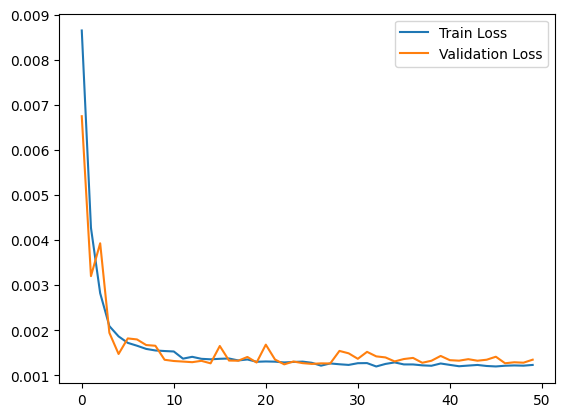

In [54]:
# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [63]:
# Predict flood probability for the test set
predictions = model.predict(X_test)

predictions = predictions.flatten()

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [56]:
# Convert back to percentages
df_test = df.iloc[split+sequence_length:]
df_test = df_test.copy()
df_test['predicted_flood_probability'] = predictions


# Display sample predictions
print(df_test[['flood_probability', 'predicted_flood_probability']].head(30))

            flood_probability  predicted_flood_probability
time                                                      
2018-10-23           0.226789                     0.224492
2018-10-24           0.226689                     0.242003
2018-10-25           0.233559                     0.248983
2018-10-26           0.279683                     0.262736
2018-10-27           0.291571                     0.300688
2018-10-28           0.315066                     0.313593
2018-10-29           0.304075                     0.334080
2018-10-30           0.293468                     0.314572
2018-10-31           0.235212                     0.292191
2018-11-01           0.288370                     0.251656
2018-11-02           0.298892                     0.295497
2018-11-03           0.319750                     0.321331
2018-11-04           0.300482                     0.341084
2018-11-05           0.289716                     0.307876
2018-11-06           0.259207                     0.3060

In [60]:
# View the high risk predictions (likely to experience flood)
high_risk_floods = df_test[df_test['predicted_flood_probability'] > 0.60]

high_risk_floods

,temperature,dew_point,humidity,wind_speed,pressure,precipitation,3_day_cum_precip,norm_precip,norm_humidity,norm_dew_point,norm_pressure,flood_probability,predicted_flood_probability
time,,,,,,,,,,,,,
2019-12-05,0.384615,0.842105,0.900000,0.185185,0.379310,0.206587,117.0,0.571848,0.928571,0.823529,0.005982,0.636942,0.635268
2019-12-06,0.538462,0.842105,0.814286,0.370370,0.275862,0.144711,97.9,0.478495,0.867347,0.823529,0.006979,0.578120,0.605183
2020-01-30,0.461538,0.789474,0.828571,0.148148,0.689655,0.434132,165.2,0.807429,0.877551,0.764706,0.002991,0.732465,0.667356
2020-01-31,0.461538,0.789474,0.800000,0.222222,0.586207,0.379242,181.7,0.888074,0.857143,0.764706,0.003988,0.768806,0.738246
2020-03-27,0.461538,0.842105,0.800000,0.370370,0.379310,0.688623,152.5,0.745357,0.857143,0.823529,0.005982,0.709411,0.613594
2020-03-28,0.538462,0.789474,0.742857,0.444444,0.482759,0.188623,145.9,0.713099,0.816327,0.764706,0.004985,0.673254,0.700982
2020-04-19,0.384615,0.842105,0.928571,0.296296,0.482759,0.708583,177.4,0.867058,0.948980,0.823529,0.004985,0.788529,0.666143
2020-04-20,0.461538,0.842105,0.814286,0.111111,0.482759,0.155689,162.0,0.791789,0.867347,0.823529,0.004985,0.734568,0.759528
2020-04-23,0.461538,0.842105,0.828571,0.370370,0.482759,0.089820,119.8,0.585533,0.877551,0.823529,0.004985,0.633481,0.684411


In [64]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error

In [65]:
# Create a copy of the scaled test data to maintain the correct shape
test_data_copy = np.zeros((y_test.shape[0], df[features].shape[1]))  # Same number of columns as original dataset
test_data_copy[:, -1] = y_test  # Only set the target variable (flood probability)
pred_data_copy = test_data_copy.copy()
pred_data_copy[:, -1] = predictions  # Replace with predicted values

In [66]:
# Perform inverse transformation to get actual probabilities
y_test_actual = scaler.inverse_transform(test_data_copy)[:, -1]
y_pred_actual = scaler.inverse_transform(pred_data_copy)[:, -1]

In [69]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
correlation = np.corrcoef(y_test_actual, y_pred_actual)[0, 1]  # Correlation between actual and predicted

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"Correlation: {correlation}")

RMSE: 3.6722848844975178
MAE: 2.8520659180000614
MSE: 13.485676272908947
Correlation: 0.9481906285927102


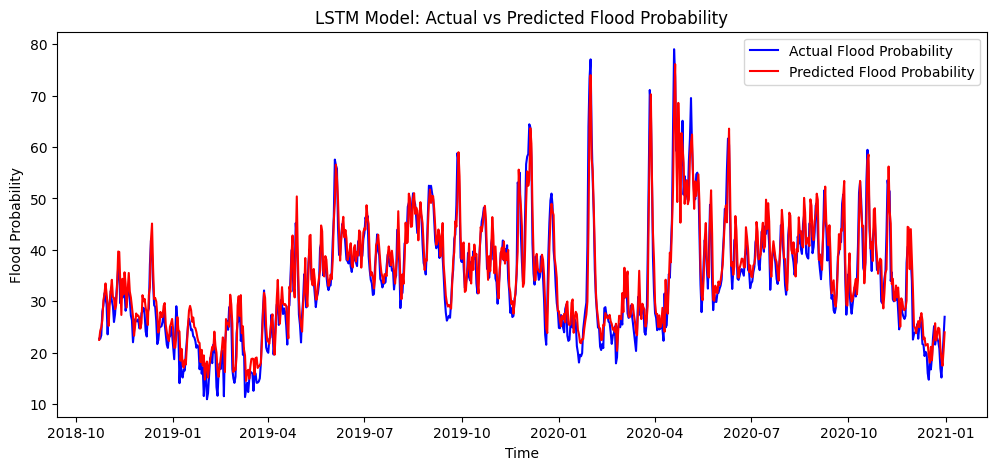

In [68]:
# Visualize Predictions vs Actual
plt.figure(figsize=(12, 5))
plt.plot(df.index[-len(y_test):], y_test_actual, label="Actual Flood Probability", color='blue')
plt.plot(df.index[-len(y_test):], y_pred_actual, label="Predicted Flood Probability", color='red')
plt.legend()
plt.title("LSTM Model: Actual vs Predicted Flood Probability")
plt.xlabel("Time")
plt.ylabel("Flood Probability")
plt.show()

In [ ]:

# Define function to classify regions based on weather characteristics
def classify_region(row):
    if (row['precipitation'] < threshold_precip_low and row['humidity'] > threshold_humidity_high and 
        row['dew_point'] > threshold_dew_high and row['wind_speed'] < threshold_wind_low and 
        row['temperature'] > threshold_temp_high):
        return 0  # Hot and Humid Zone
    elif (row['precipitation'] < threshold_precip_low and row['humidity'] < threshold_humidity_low and 
          row['dew_point'] < threshold_dew_low and row['wind_speed'] > threshold_wind_high and 
          row['temperature'] < threshold_temp_low):
        return 1  # Cool and Windy Zone
    elif (row['precipitation'] < threshold_precip_low and threshold_humidity_low <= row['humidity'] <= threshold_humidity_high and 
          threshold_dew_low <= row['dew_point'] <= threshold_dew_high and threshold_wind_low <= row['wind_speed'] <= threshold_wind_high and 
          row['temperature'] > threshold_temp_high):
        return 2  # Warm and Moderate Zone
    else:
        return 3  # Rain-Prone Cool Zone

# Define threshold values based on dataset statistics
threshold_precip_low = df['precipitation'].quantile(0.4)
threshold_humidity_high = df['humidity'].quantile(0.6)
threshold_humidity_low = df['humidity'].quantile(0.4)
threshold_dew_high = df['dew_point'].quantile(0.6)
threshold_dew_low = df['dew_point'].quantile(0.4)
threshold_wind_high = df['wind_speed'].quantile(0.6)
threshold_wind_low = df['wind_speed'].quantile(0.4)
threshold_temp_high = df['temperature'].quantile(0.6)
threshold_temp_low = df['temperature'].quantile(0.4)

# Assign each row to a region
df['region'] = df.apply(classify_region, axis=1)

# Compute flood probability per region
df_grouped = df.groupby('region').apply(calculate_flood_probability)

# Reset index after applying function
df_grouped.reset_index(drop=True, inplace=True)

# Save updated dataset
df_grouped.to_csv('regional_flood_probabilities.csv')


In [ ]:

# Load the clustered dataset
df = pd.read_csv('baringo_clustered_data.csv')

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Define flood probability function
def calculate_flood_probability(df):
    df['3_day_cum_precip'] = df['precipitation'].rolling(window=3).sum()

    # Normalize features (min-max scaling)
    df['norm_precip'] = df['3_day_cum_precip'] / df['3_day_cum_precip'].max()
    df['norm_humidity'] = df['humidity'] / df['humidity'].max()
    df['norm_dew_point'] = df['dew_point'] / df['dew_point'].max()
    df['norm_pressure'] = 1 - (df['pressure'] / df['pressure'].max())  # Inverse scaling

    # Weighted sum of features (tuned weights based on analysis)
    df['flood_probability'] = (
        (df['norm_precip'] * 0.5) + 
        (df['norm_humidity'] * 0.2) + 
        (df['norm_dew_point'] * 0.2) + 
        (df['norm_pressure'] * 0.1)
    )

    # Clip values to ensure probability range (0 to 1)
    df['flood_probability'] = df['flood_probability'].clip(0, 1)

    return df

# Compute flood probability per region
df_grouped = df.groupby('region_id', group_keys=False).apply(calculate_flood_probability)

# Save updated dataset
df_grouped.to_csv('regional_flood_predictions.csv', index=False)

# Display sample output
df_grouped.head()
